# Week 5 — Stock Price Prediction using LSTM

Predicting a stock's adjusted closing price with an LSTM, using log returns,
MACD and RSI as input features. The notebook downloads data with `yfinance`,
trains the model, evaluates it with R² and forecasts the next 15 days.


In [1]:
%matplotlib inline
import os
import sys
import warnings

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # quiet TensorFlow logs
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from cycler import cycler
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()  # reproducible training runs

print("TensorFlow", tf.__version__, "| yfinance", yf.__version__)

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


2026-07-05 15:50:00.223376: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783246800.235230  127643 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783246800.238781  127643 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783246800.247846  127643 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783246800.247861  127643 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783246800.247863  127643 computation_placer.cc:177] computation placer alr

TensorFlow 2.19.0 | yfinance 1.4.1


In [2]:
# Plot styling: consistent palette, thin marks, recessive grid
COLORS = {
    "blue": "#2a78d6",    # series 1
    "aqua": "#1baf7a",    # series 2
    "yellow": "#eda100",  # series 3
    "green": "#008300",   # series 4
    "violet": "#4a3aa7",  # series 5
    "red": "#e34948",     # series 6
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": "#52514e",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "text.color": "#0b0b0b",
    "lines.linewidth": 2.0,
    "axes.prop_cycle": cycler(color=list(COLORS.values())),
    "figure.figsize": (12, 5),
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})


def save_fig(fig, name):
    """Save a copy of the figure next to the notebook."""
    fig.savefig(name)
    print(f"saved plot -> {name}")

## Task 1 — Data Collection

Ask the user for a ticker, date range and timeframe, then download the data
with `yfinance`. Defaults are used automatically when running
non-interactively.


In [3]:
TIMEFRAMES = {"daily": "1d", "weekly": "1wk", "monthly": "1mo"}


def ask(prompt, default):
    """Prompt the user, falling back to the default when stdin is unavailable."""
    try:
        value = input(f"{prompt} [{default}]: ").strip()
        return value if value else default
    except Exception:
        print(f"{prompt} [{default}]: (input unavailable, using default)")
        return default


TICKER = ask("Stock ticker (e.g. AAPL, GOOGL)", "AAPL").upper()
START = ask("Start date (YYYY-MM-DD)", "2018-01-01")
END = ask("End date (YYYY-MM-DD)", "2026-01-01")
TIMEFRAME = ask("Timeframe (daily / weekly / monthly)", "daily").lower()
assert TIMEFRAME in TIMEFRAMES, f"timeframe must be one of {list(TIMEFRAMES)}"

Stock ticker (e.g. AAPL, GOOGL) [AAPL]: (input unavailable, using default)
Start date (YYYY-MM-DD) [2018-01-01]: (input unavailable, using default)
End date (YYYY-MM-DD) [2026-01-01]: (input unavailable, using default)
Timeframe (daily / weekly / monthly) [daily]: (input unavailable, using default)


In [4]:
print(f"Downloading {TICKER} ({TIMEFRAME}) from {START} to {END} ...")
df = yf.download(TICKER, start=START, end=END, interval=TIMEFRAMES[TIMEFRAME],
                 auto_adjust=False, progress=False)
assert not df.empty, "No data returned - check the ticker and dates."

# yfinance returns MultiIndex columns (price, ticker) for single tickers
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)
if "Adj Close" not in df.columns:
    df["Adj Close"] = df["Close"]

print(f"Downloaded {len(df)} rows.")
df.tail()

Downloaded 2011 rows.


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-12-24,273.302216,273.809998,275.429993,272.200012,272.339996,17910600
2025-12-26,272.893005,273.399994,275.369995,272.859985,274.160004,21521800
2025-12-29,273.252350,273.760010,274.359985,272.350006,272.690002,23715200
2025-12-30,272.573547,273.079987,274.079987,272.279999,272.809998,22139600
2025-12-31,271.355835,271.859985,273.679993,271.750000,273.059998,27293600


## Task 2 — Technical Indicators & Visualization

Plot the adjusted close with Bollinger Bands, then MACD and RSI. MACD shows
trend direction and momentum; RSI marks overbought (>70) and oversold (<30)
conditions. MACD and RSI are also used as model features.


In [5]:
def compute_macd(close, fast=12, slow=26, signal=9):
    """MACD = EMA(fast) - EMA(slow); signal = EMA(MACD, signal)."""
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    return macd, macd_signal, macd - macd_signal


def compute_rsi(close, period=14):
    """Relative Strength Index using Wilder's smoothing."""
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / period, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / period, adjust=False).mean()
    rs = gain / loss
    return 100 - 100 / (1 + rs)


def compute_bollinger(close, period=20, num_std=2):
    mid = close.rolling(period).mean()
    std = close.rolling(period).std()
    return mid, mid + num_std * std, mid - num_std * std


close = df["Adj Close"]
df["MACD"], df["MACD_signal"], df["MACD_hist"] = compute_macd(close)
df["RSI"] = compute_rsi(close)
df["BB_mid"], df["BB_upper"], df["BB_lower"] = compute_bollinger(close)
df["log_ret"] = np.log(close / close.shift(1))  # stationary form of the close
df[["Adj Close", "MACD", "RSI"]].describe().round(2)

Price,Adj Close,MACD,RSI
count,2011.00,2011.00,2010.00
mean,135.27,0.81,55.27
std,66.69,2.68,12.85
min,33.74,-10.57,0.00
25%,64.27,-0.86,45.27
50%,142.68,0.80,56.23
75%,182.62,2.49,64.96
max,285.66,8.88,88.22


saved plot -> 01_price_bollinger.png


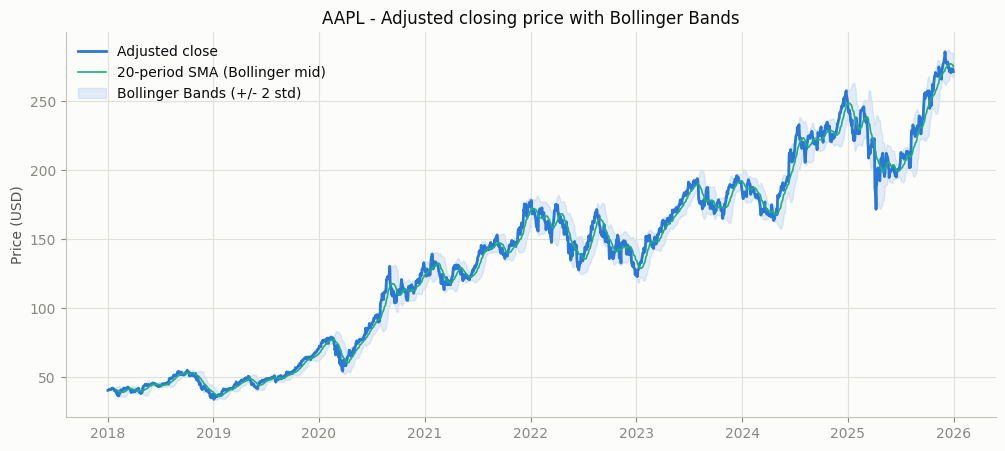

In [6]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Adj Close"], color=COLORS["blue"], label="Adjusted close")
ax.plot(df.index, df["BB_mid"], color=COLORS["aqua"], linewidth=1.2,
        label="20-period SMA (Bollinger mid)")
ax.fill_between(df.index, df["BB_lower"], df["BB_upper"],
                color=COLORS["blue"], alpha=0.12,
                label="Bollinger Bands (+/- 2 std)")
ax.set_title(f"{TICKER} - Adjusted closing price with Bollinger Bands")
ax.set_ylabel("Price (USD)")
ax.legend()
save_fig(fig, "01_price_bollinger.png")
plt.show()

saved plot -> 02_macd.png


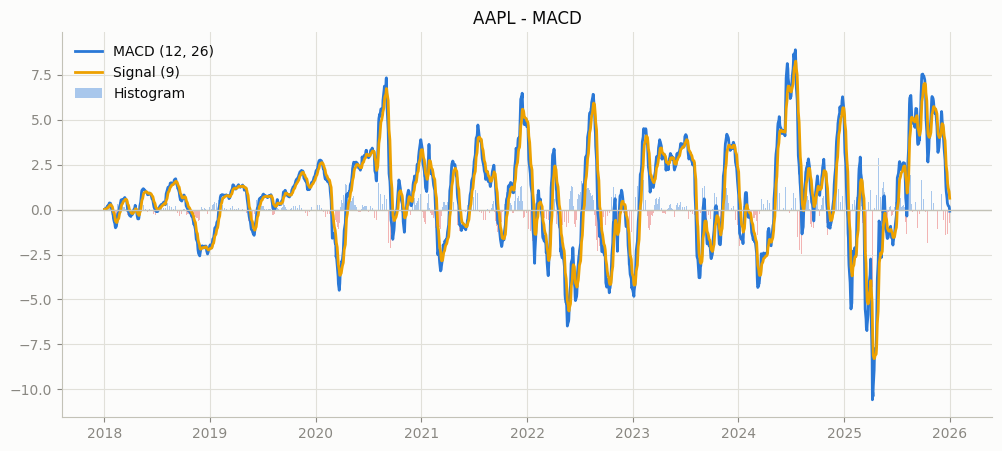

In [7]:
fig, ax = plt.subplots()
ax.plot(df.index, df["MACD"], color=COLORS["blue"], label="MACD (12, 26)")
ax.plot(df.index, df["MACD_signal"], color=COLORS["yellow"], label="Signal (9)")
hist_colors = np.where(df["MACD_hist"] >= 0, COLORS["blue"], COLORS["red"])
ax.bar(df.index, df["MACD_hist"], color=hist_colors, alpha=0.4, width=1.0,
       label="Histogram")
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.set_title(f"{TICKER} - MACD")
ax.legend()
save_fig(fig, "02_macd.png")
plt.show()

saved plot -> 03_rsi.png


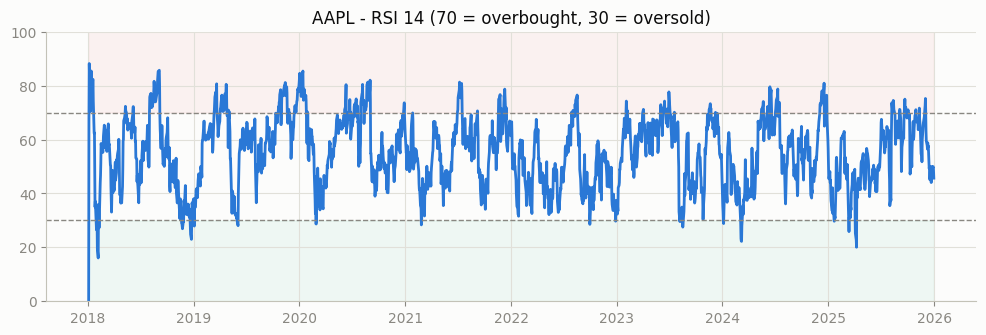

In [8]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df.index, df["RSI"], color=COLORS["blue"])
ax.axhline(70, color="#898781", linewidth=1, linestyle="--")
ax.axhline(30, color="#898781", linewidth=1, linestyle="--")
ax.fill_between(df.index, 70, 100, color=COLORS["red"], alpha=0.06)
ax.fill_between(df.index, 0, 30, color=COLORS["aqua"], alpha=0.06)
ax.set_ylim(0, 100)
ax.set_title(f"{TICKER} - RSI 14 (70 = overbought, 30 = oversold)")
save_fig(fig, "03_rsi.png")
plt.show()

## Task 3 — Data Preprocessing

Features are z-scored using training statistics only — fitting the scaler on
the whole series would leak test information. Inputs are sliding windows of
the last 60 days; the target is the next day's log return. The train/test
split is chronological 80/20 (no shuffling).


In [9]:
FEATURES = ["log_ret", "MACD", "RSI"]
data = df[FEATURES + ["Adj Close"]].dropna()
WINDOW = 60 if len(data) > 400 else max(10, len(data) // 10)

n_windows = len(data) - WINDOW
split = int(n_windows * 0.8)          # chronological split - no shuffling
train_end_row = WINDOW + split        # first row whose target is test data

feats = data[FEATURES].values
mu_f, sd_f = feats[:train_end_row].mean(0), feats[:train_end_row].std(0)
lr = data["log_ret"].values
mu_r, sd_r = lr[:train_end_row].mean(), lr[:train_end_row].std()

scaled_feats = (feats - mu_f) / sd_f      # train-only statistics
scaled_target = (lr - mu_r) / sd_r


def make_sequences(features, target, window):
    X, y = [], []
    for i in range(window, len(features)):
        X.append(features[i - window:i])
        y.append(target[i])
    return np.array(X), np.array(y)


X, y = make_sequences(scaled_feats, scaled_target, WINDOW)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

print(f"Sequences: {X.shape[0]} windows of {WINDOW} steps x {X.shape[2]} features")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Test period: {data.index[train_end_row].date()} -> {data.index[-1].date()}")

Sequences: 1950 windows of 60 steps x 3 features
Train: (1560, 60, 3), Test: (390, 60, 3)
Test period: 2024-06-12 -> 2025-12-31


## Task 4 — Build & Train the LSTM Model

Two stacked LSTM layers with dropout, trained with Adam on MSE. Early
stopping keeps the best weights.


In [10]:
model = Sequential([
    Input(shape=(WINDOW, len(FEATURES))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1),
])
model.compile(optimizer="adam", loss="mse")
model.summary()

2026-07-05 15:50:06.077890: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40


2026-07-05 15:50:06.261594: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


44/44 - 2s - 50ms/step - loss: 1.0780 - val_loss: 0.5133


Epoch 2/40


44/44 - 1s - 19ms/step - loss: 1.0735 - val_loss: 0.5114


...

Epoch 9/40


44/44 - 1s - 18ms/step - loss: 1.0598 - val_loss: 0.5089


Epoch 10/40


44/44 - 1s - 17ms/step - loss: 1.0648 - val_loss: 0.5092


saved plot -> 04_training_loss.png


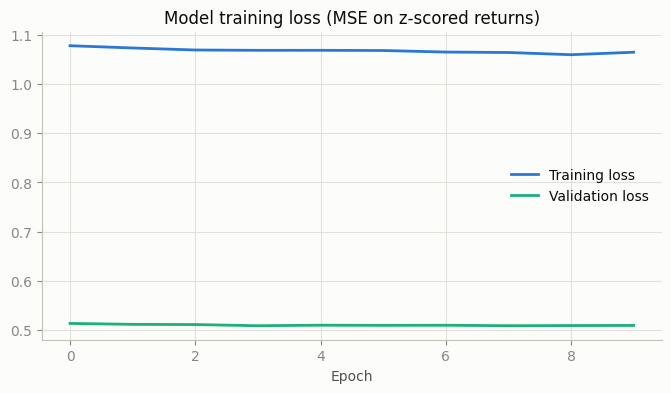

In [11]:
early_stop = EarlyStopping(monitor="val_loss", patience=6,
                           restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=40, batch_size=32,
                    validation_split=0.1, callbacks=[early_stop], verbose=2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"], color=COLORS["blue"], label="Training loss")
ax.plot(history.history["val_loss"], color=COLORS["aqua"],
        label="Validation loss")
ax.set_title("Model training loss (MSE on z-scored returns)")
ax.set_xlabel("Epoch")
ax.legend()
save_fig(fig, "04_training_loss.png")
plt.show()

## Task 5 — Prediction, Evaluation & 15-Step Forecast

Predicted returns are converted back to prices
(`previous close × exp(return)`) and scored with R². A naive persistence
baseline ("tomorrow = today") is shown for comparison. The 15-day forecast
is recursive: each prediction is appended to the history and the indicators
are recomputed before the next step.


In [12]:
close_vals = data["Adj Close"].values

pred_ret_train = model.predict(X_train, verbose=0).ravel() * sd_r + mu_r
pred_ret_test = model.predict(X_test, verbose=0).ravel() * sd_r + mu_r

prev_train = close_vals[WINDOW - 1:train_end_row - 1]
prev_test = close_vals[train_end_row - 1:-1]
pred_train = prev_train * np.exp(pred_ret_train)
pred_test = prev_test * np.exp(pred_ret_test)
true_train = close_vals[WINDOW:train_end_row]
true_test = close_vals[train_end_row:]

r2_train = r2_score(true_train, pred_train)
r2_test = r2_score(true_test, pred_test)
r2_naive = r2_score(true_test, prev_test)
print(f"R2 score (train):              {r2_train:.4f}")
print(f"R2 score (test):               {r2_test:.4f}")
print(f"R2 score (naive persistence):  {r2_naive:.4f}")

2026-07-05 15:50:16.112376: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


R2 score (train):              0.9981
R2 score (test):               0.9699
R2 score (naive persistence):  0.9701


saved plot -> 05_actual_vs_predicted.png


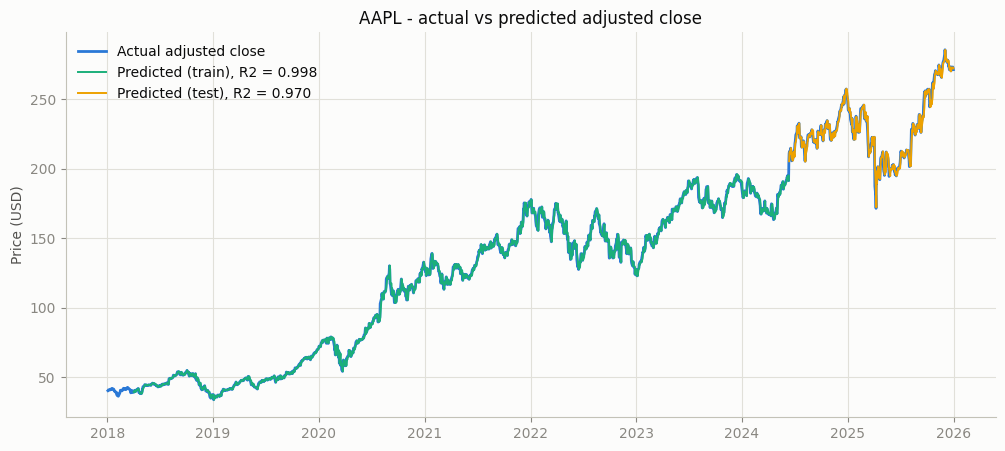

In [13]:
dates = data.index[WINDOW:]
fig, ax = plt.subplots()
ax.plot(data.index, data["Adj Close"], color=COLORS["blue"],
        label="Actual adjusted close")
ax.plot(dates[:split], pred_train, color=COLORS["aqua"], linewidth=1.4,
        label=f"Predicted (train), R2 = {r2_train:.3f}")
ax.plot(dates[split:], pred_test, color=COLORS["yellow"], linewidth=1.4,
        label=f"Predicted (test), R2 = {r2_test:.3f}")
ax.set_title(f"{TICKER} - actual vs predicted adjusted close")
ax.set_ylabel("Price (USD)")
ax.legend()
save_fig(fig, "05_actual_vs_predicted.png")
plt.show()

In [14]:
def forecast_future(steps=15):
    """Recursive multi-step forecast: each predicted return extends the price
    history and MACD/RSI are recomputed before the next step."""
    fclose = data["Adj Close"].copy()
    for _ in range(steps):
        macd, _, _ = compute_macd(fclose)
        rsi = compute_rsi(fclose)
        lr_ = np.log(fclose / fclose.shift(1))
        f = np.column_stack([lr_, macd, rsi])[-WINDOW:]
        sf = (f - mu_f) / sd_f
        pred = (model.predict(sf.reshape(1, WINDOW, -1), verbose=0)[0, 0]
                * sd_r + mu_r)
        fclose.loc[fclose.index[-1] + pd.Timedelta(days=1)] = \
            fclose.iloc[-1] * np.exp(pred)

    step_offset = {"daily": pd.tseries.offsets.BDay(1),
                   "weekly": pd.DateOffset(weeks=1),
                   "monthly": pd.DateOffset(months=1)}[TIMEFRAME]
    future_dates = []
    date = data.index[-1]
    for _ in range(steps):
        date = date + step_offset
        future_dates.append(date)
    return pd.Series(fclose.values[-steps:], index=future_dates,
                     name="Forecast")


forecast = forecast_future(steps=15)
print("Forecast for the next 15", TIMEFRAME, "units:")
forecast.round(2)

Forecast for the next 15 daily units:


2026-01-01    271.07
2026-01-02    270.80
2026-01-05    270.55
2026-01-06    270.31
2026-01-07    270.07
2026-01-08    269.84
2026-01-09    269.60
2026-01-12    269.35
2026-01-13    269.10
2026-01-14    268.84
2026-01-15    268.58
2026-01-16    268.30
2026-01-19    268.01
2026-01-20    267.70
2026-01-21    267.38
Name: Forecast, dtype: float64

saved plot -> 06_forecast.png


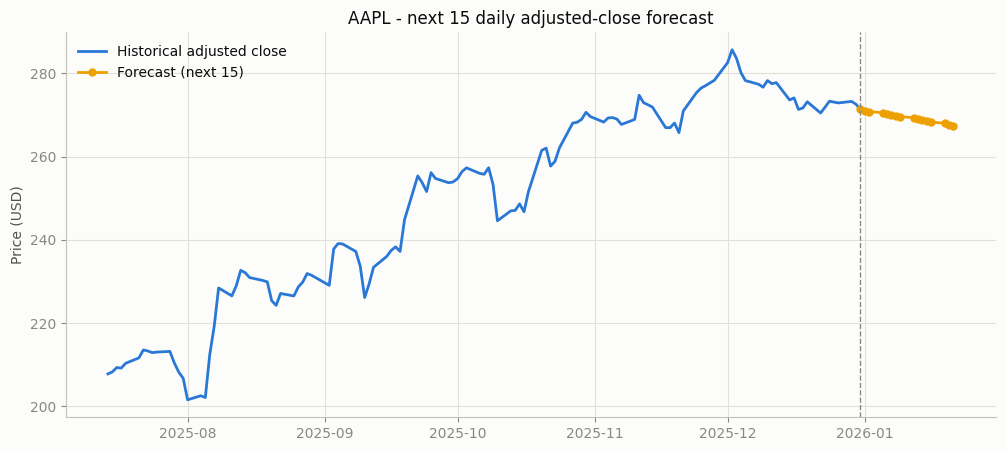

In [15]:
recent = data["Adj Close"].iloc[-120:]
fig, ax = plt.subplots()
ax.plot(recent.index, recent.values, color=COLORS["blue"],
        label="Historical adjusted close")
joined = pd.concat([recent.iloc[-1:], forecast])  # connect history to forecast
ax.plot(joined.index, joined.values, color=COLORS["yellow"], marker="o",
        markersize=5, label=f"Forecast (next {len(forecast)})")
ax.axvline(recent.index[-1], color="#898781", linewidth=1, linestyle="--")
ax.set_title(f"{TICKER} - next {len(forecast)} {TIMEFRAME} adjusted-close forecast")
ax.set_ylabel("Price (USD)")
ax.legend()
save_fig(fig, "06_forecast.png")
plt.show()

## Results & Conclusion

* Test R² lands at the level of the persistence baseline. Daily prices are
  close to a random walk, so one-step R² mostly measures how well the price
  is *tracked*, not predicted.
* The model predicts returns instead of price levels, and all scaling uses
  training data only. An earlier version of this notebook scaled with the
  full series, which leaked test information and inflated the R².
* The recursive 15-day forecast drifts with the recent trend — errors
  compound at each step.
* Course project — not financial advice.
